In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from truckscenes import TruckScenes
import importlib

import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import METADATA_ROOT, DATA_ROOT, VERSION
from src.data_io import load_json
from src.annotation_velocity import build_annotation_trajectory_df
from src.sensor_observation import build_sensor_data_df
from src.camera import build_camera_target_df
from src.detectability import filter_objects
from src.visualisation import (
    load_sample_lidar_points,
    plot_lidar_bev,
    plot_lidar_3d,
    get_sample_boxes_ego,
    plot_lidar_bev_with_boxes,
    plot_lidar_3d_with_boxes, 
)

# 1. Analysis Factor Inspection

In [2]:
scenes = load_json(METADATA_ROOT / "scene.json")
samples = load_json(METADATA_ROOT / "sample.json")
annotations = load_json(METADATA_ROOT / "sample_annotation.json")
instances = load_json(METADATA_ROOT / "instance.json")
categories = load_json(METADATA_ROOT / "category.json")
visibility = load_json(METADATA_ROOT / "visibility.json")

print("Scenes:", len(scenes))
print("Samples:", len(samples))
print("Annotations:", len(annotations))
print("Instances:", len(instances))
print("Categories:", len(categories))

Scenes: 10
Samples: 400
Annotations: 25750
Instances: 1094
Categories: 27


In [3]:
def parse_scene_description(description):
    return {
        item.split(".", 1)[0]: item.split(".", 1)[1]
        for item in description.split(";")
        if "." in item
    }


scene_condition_df = pd.DataFrame([
    {
        "scene_token": scene["token"],
        **parse_scene_description(scene["description"]),
    }
    for scene in scenes
])

for condition in ["weather", "area", "lighting"]:
    print(f"\n{condition.upper()}")
    print(scene_condition_df[condition].value_counts())


WEATHER
weather
clear       4
overcast    3
rain        2
snow        1
Name: count, dtype: int64

AREA
area
highway     4
city        4
terminal    2
Name: count, dtype: int64

LIGHTING
lighting
illuminated       7
dark              1
twilight          1
other_lighting    1
Name: count, dtype: int64


In [4]:
instance_lookup = {record["token"]: record for record in instances}
category_lookup = {record["token"]: record["name"] for record in categories}
visibility_lookup = {record["token"]: record["level"] for record in visibility}

object_factors = pd.DataFrame([
    {
        "category": category_lookup[
            instance_lookup[annotation["instance_token"]]["category_token"]
        ],
        "visibility": visibility_lookup[annotation["visibility_token"]],
    }
    for annotation in annotations
])

print("OBJECT TYPES")
print(object_factors["category"].value_counts())

print("\nVISIBILITY")
print(object_factors["visibility"].value_counts().sort_index())

OBJECT TYPES
category
vehicle.car                             11811
static_object.traffic_sign               6666
vehicle.truck                            2230
vehicle.trailer                          1468
human.pedestrian.adult                   1000
movable_object.trafficcone                857
vehicle.bus.rigid                         379
vehicle.ego_trailer                       360
vehicle.train                             200
human.pedestrian.construction_worker      172
vehicle.bicycle                           134
vehicle.construction                      132
human.pedestrian.child                     82
vehicle.motorcycle                         80
vehicle.other                              67
movable_object.barrier                     42
human.pedestrian.stroller                  39
animal                                     31
Name: count, dtype: int64

VISIBILITY
visibility
1     8346
2     2176
3     2034
4    13194
Name: count, dtype: int64


# 2. Object-Level Sensor Table

In [5]:
truckscenes = TruckScenes(
    version=VERSION,
    dataroot=str(DATA_ROOT),
    verbose=False,
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [6]:
object_df = build_annotation_trajectory_df(
    samples,
    annotations,
    instances,
    categories,
)

annotation_info = pd.DataFrame([
    {
        "annotation_token": annotation["token"],
        "visibility_level": visibility_lookup[annotation["visibility_token"]],
        "num_lidar_pts": annotation["num_lidar_pts"],
        "num_radar_pts": annotation["num_radar_pts"],
    }
    for annotation in annotations
])

sample_to_scene = {
    sample["token"]: sample["scene_token"]
    for sample in samples
}

object_df["scene_token"] = object_df["sample_token"].map(sample_to_scene)

object_df = (
    object_df
    .merge(annotation_info, on="annotation_token", how="left")
    .merge(
        scene_condition_df[
            ["scene_token", "weather", "area", "lighting"]
        ],
        on="scene_token",
        how="left",
    )
)

In [7]:
sample_to_ego_xy = {
    sample["token"]: truckscenes.getclosest(
        "ego_pose",
        sample["timestamp"],
    )["translation"][:2]
    for sample in samples
}

object_df["ego_x"] = object_df["sample_token"].map(
    lambda token: sample_to_ego_xy[token][0]
)

object_df["ego_y"] = object_df["sample_token"].map(
    lambda token: sample_to_ego_xy[token][1]
)

object_df["distance_m"] = (
    (object_df["x"] - object_df["ego_x"]) ** 2
    + (object_df["y"] - object_df["ego_y"]) ** 2
) ** 0.5

object_df = object_df.drop(columns=["ego_x", "ego_y"])

In [8]:
sensor_data_df = build_sensor_data_df()

camera_keyframes = sensor_data_df[
    (sensor_data_df["Modality"] == "Camera")
    & sensor_data_df["Is Key Frame"]
].copy()

camera_view_df, target_camera_df = build_camera_target_df(
    truckscenes,
    object_df,
    camera_keyframes,
)

object_df = object_df.merge(
    target_camera_df[
        [
            "annotation_token",
            "camera_view_count",
            "has_camera_information",
            "camera_projected_area_px",
        ]
    ],
    on="annotation_token",
    how="left",
    validate="one_to_one",
)

object_df = object_df.rename(
    columns={"has_camera_information": "camera_observable"}
)

In [9]:
object_df = object_df[
    [
        "scene_token",
        "sample_token",
        "annotation_token",
        "instance_token",
        "category",
        "distance_m",
        "weather",
        "area",
        "lighting",
        "visibility_level",
        "num_lidar_pts",
        "num_radar_pts",
        "camera_view_count",
        "camera_observable",
        "camera_projected_area_px",
    ]
]

display(object_df.head())

,scene_token,sample_token,annotation_token,instance_token,category,distance_m,weather,area,lighting,visibility_level,num_lidar_pts,num_radar_pts,camera_view_count,camera_observable,camera_projected_area_px
0,044c648ac12345f1aedf33c9f91cdc5a,32d2bcf46e734dffb14fe2e0a823d059,50873dd5195b47bc9544ac2821e054e0,163b7c695f7243779ef5e5f0fd844063,vehicle.car,23.477812,clear,terminal,illuminated,4,430,2,2,True,12277.760203
1,044c648ac12345f1aedf33c9f91cdc5a,deb7b3f332f042d49e7636d6e4959354,9f0e8f997dc647bf9a0a20c679b1804d,163b7c695f7243779ef5e5f0fd844063,vehicle.car,22.129977,clear,terminal,illuminated,4,567,3,2,True,15109.064334
2,044c648ac12345f1aedf33c9f91cdc5a,a574551be31547e4b7c78ff87c75abb3,2c8422f4ac674f949fa1124dcaa1fa5e,163b7c695f7243779ef5e5f0fd844063,vehicle.car,20.596144,clear,terminal,illuminated,4,765,1,2,True,19535.174994
3,044c648ac12345f1aedf33c9f91cdc5a,1393759bf6ff4f8e88deff0da0dc2aca,c4d5f41838054ff581106dc5e0ed10c2,163b7c695f7243779ef5e5f0fd844063,vehicle.car,19.102264,clear,terminal,illuminated,4,1040,2,2,True,25372.468303
4,044c648ac12345f1aedf33c9f91cdc5a,368662645c194921b716c026347db664,384bb8f773d640bd851c2581d8750294,163b7c695f7243779ef5e5f0fd844063,vehicle.car,17.477420,clear,terminal,illuminated,4,1418,6,2,True,35840.529148


In [10]:
print("Rows:", len(object_df))
print("Unique annotations:", object_df["annotation_token"].nunique())
print("Missing values:", object_df.isna().sum().sum())

print("\nCamera projected area:")
print(
    object_df
    .groupby("camera_observable")["camera_projected_area_px"]
    .agg(["count", "min", "median", "max"])
)

Rows: 25750
Unique annotations: 25750
Missing values: 0

Camera projected area:
                   count       min       median           max
camera_observable                                            
False                621  0.000000     0.000000  0.000000e+00
True               25129  0.345591  1100.520963  1.561575e+06


# 3. Existing Function Reuse

Existing project modules are reused for Ground Truth object information, sensor metadata, Camera support, LiDAR point-cloud loading, RADAR point-cloud loading, and velocity analysis. New code in this notebook focuses only on filtering, cross-sensor visualisation, and integration.

# 4. Conditional Object Filtering

Ground Truth objects can be filtered by weather, area, visibility, object type, and distance. The filtered objects and corresponding sample tokens are returned for subsequent cross-sensor analysis.

In [11]:
filtered_objects, sample_tokens = filter_objects(
    object_df,
    category="vehicle.truck",
    distance_range=(20, 40),
)

print("Matching objects:", len(filtered_objects))
print("Matching samples:", len(sample_tokens))

assert len(sample_tokens) == filtered_objects["sample_token"].nunique()

display(
    filtered_objects[
        [
            "category",
            "distance_m",
            "weather",
            "area",
            "visibility_level",
            "num_lidar_pts",
            "num_radar_pts",
            "camera_observable",
        ]
    ].head()
)

Matching objects: 476
Matching samples: 249


,category,distance_m,weather,area,visibility_level,num_lidar_pts,num_radar_pts,camera_observable
0,vehicle.truck,39.215645,clear,terminal,4,502,0,True
1,vehicle.truck,37.775517,clear,terminal,4,560,3,True
2,vehicle.truck,36.108292,clear,terminal,4,687,2,True
3,vehicle.truck,34.365214,clear,terminal,4,895,4,True
4,vehicle.truck,32.803205,clear,terminal,4,850,2,True


# 5. Filter Combination Test

Several representative filter combinations are tested to confirm that the object-level filtering workflow returns valid Ground Truth objects and corresponding samples.

In [12]:
test_cases = [
    {
        "name": "Clear + Highway",
        "filters": {
            "weather": "clear",
            "area": "highway",
        },
    },
    {
        "name": "Rain + Highway",
        "filters": {
            "weather": "rain",
            "area": "highway",
        },
    },
    {
        "name": "Truck + 20–40 m",
        "filters": {
            "category": "vehicle.truck",
            "distance_range": (20, 40),
        },
    },
    {
        "name": "Car + 40 m+",
        "filters": {
            "category": "vehicle.car",
            "distance_range": (40, None),
        },
    },
]

results = []

for case in test_cases:
    filtered, samples_found = filter_objects(
        object_df,
        **case["filters"],
    )

    results.append({
        "Filter": case["name"],
        "Matching Objects": len(filtered),
        "Matching Samples": len(samples_found),
    })

filter_test_summary = pd.DataFrame(results)

display(filter_test_summary)

,Filter,Matching Objects,Matching Samples
0,Clear + Highway,1289,40
1,Rain + Highway,2975,40
2,Truck + 20–40 m,476,249
3,Car + 40 m+,9200,391


# 6. Sample Selection and Sensor Retrieval

A matching sample is selected from the filtered Ground Truth objects. Camera, LiDAR, RADAR, and annotation records for the same sample are then identified for cross-sensor visualisation.

In [13]:
filtered_objects, sample_tokens = filter_objects(
    object_df,
    category="vehicle.truck",
    distance_range=(20, 40),
)

selected_sample_token = sample_tokens[0]

print("Selected sample:", selected_sample_token)

Selected sample: a42b482121464aa795d24f55400c574f


In [14]:
sample_objects = object_df[
    object_df["sample_token"] == selected_sample_token
].copy()

display(
    sample_objects[
        [
            "annotation_token",
            "category",
            "distance_m",
            "visibility_level",
            "num_lidar_pts",
            "num_radar_pts",
            "camera_observable",
        ]
    ]
)

,annotation_token,category,distance_m,visibility_level,num_lidar_pts,num_radar_pts,camera_observable
5,dab1ddee5ab1471bbc27bf7942e7d920,vehicle.car,15.912815,4,2038,8,True
39,03ec66d5a3c14a6f9460333be8a70396,human.pedestrian.adult,44.115549,2,25,0,True
69,4daad8d13d4e470185588136e80a36ca,vehicle.truck,39.215645,4,502,0,True
109,f30bf2d8b5b84e3a8a7ac0cd857beeda,human.pedestrian.adult,16.944294,4,432,4,True
149,3f5f113cf01f4c20b7c71a4952dae319,vehicle.trailer,34.996595,4,280,13,True
189,76c11c443fd94afc9e7ffcc508f96dc1,vehicle.truck,47.914481,4,536,9,True
228,0ee4d4f459d94c3a82b6c84c1257ca96,movable_object.trafficcone,6.854074,4,16,0,True
260,61f044e78b65445491f493f5f839c1d1,vehicle.truck,22.262005,4,877,6,True
300,ecfc9b56a80a486880de97f6567e6a06,vehicle.trailer,17.804581,4,2958,36,True
335,ceff366931214874b6456db534c65304,vehicle.trailer,50.629086,2,533,6,True


In [15]:
sample_sensor_data = sensor_data_df[
    (sensor_data_df["Sample Token"] == selected_sample_token)
    & sensor_data_df["Is Key Frame"]
].copy()

display(
    sample_sensor_data[
        [
            "Modality",
            "Sensor",
            "Token",
            "Filename",
        ]
    ]
)

,Modality,Sensor,Token,Filename
54,RADAR,RADAR_RIGHT_BACK,5db407cf84714a359477dd591aebd4f1,samples/RADAR_RIGHT_BACK/RADAR_RIGHT_BACK_1695...
426,RADAR,RADAR_RIGHT_SIDE,dc59b85dde3c40679dc56e69111a4443,samples/RADAR_RIGHT_SIDE/RADAR_RIGHT_SIDE_1695...
814,RADAR,RADAR_RIGHT_FRONT,d2c35f96b3ef412284bdfdd6a919a377,samples/RADAR_RIGHT_FRONT/RADAR_RIGHT_FRONT_16...
1175,RADAR,RADAR_LEFT_FRONT,eea15ef65ca847e3bad72da1df2e74be,samples/RADAR_LEFT_FRONT/RADAR_LEFT_FRONT_1695...
1534,RADAR,RADAR_LEFT_SIDE,4330c46ad2de4d1889c36536103143bc,samples/RADAR_LEFT_SIDE/RADAR_LEFT_SIDE_169547...
1900,RADAR,RADAR_LEFT_BACK,fc5be5ef9bed475488b2a9e9e83d9d61,samples/RADAR_LEFT_BACK/RADAR_LEFT_BACK_169547...
2252,LiDAR,LIDAR_LEFT,a3bb413a27de45b29d1b6d15bb512fc9,samples/LIDAR_LEFT/LIDAR_LEFT_1695473375187731...
2454,LiDAR,LIDAR_RIGHT,abe808ddf6e44ca580f925c3b69718ee,samples/LIDAR_RIGHT/LIDAR_RIGHT_16954733752123...
2655,LiDAR,LIDAR_TOP_FRONT,de807f8837154267b1397e76649f4193,samples/LIDAR_TOP_FRONT/LIDAR_TOP_FRONT_169547...
2856,LiDAR,LIDAR_TOP_LEFT,618c93d05faa42b9b7e5e36028f8691f,samples/LIDAR_TOP_LEFT/LIDAR_TOP_LEFT_16954733...


In [16]:
available_modalities = set(sample_sensor_data["Modality"])

print("Available modalities:", available_modalities)

assert "Camera" in available_modalities
assert "LiDAR" in available_modalities
assert "RADAR" in available_modalities

Available modalities: {'Camera', 'LiDAR', 'RADAR'}


# 7. LiDAR Bird's-Eye View

Real LiDAR point clouds from all keyframe LiDAR sensors are transformed into the ego-vehicle coordinate frame and combined into a single Bird's-Eye View.

In [17]:
lidar_points = load_sample_lidar_points(
    truckscenes,
    sample_sensor_data,
)

print("LiDAR points:", len(lidar_points))
print("LiDAR sensors:", lidar_points["sensor"].nunique())

display(lidar_points.head())

LiDAR points: 240862
LiDAR sensors: 6


,x,y,z,intensity,timestamp,sensor
0,5.000739,-3.283634,0.036541,0.000000,1695473375225739,LIDAR_LEFT
1,5.016699,-3.283756,0.036249,0.015686,1695473375225683,LIDAR_LEFT
2,5.033300,-3.298291,0.029113,0.027451,1695473375225627,LIDAR_LEFT
3,5.048511,-3.298299,0.028835,0.031373,1695473375225572,LIDAR_LEFT
4,5.064507,-3.301870,0.026835,0.031373,1695473375225516,LIDAR_LEFT


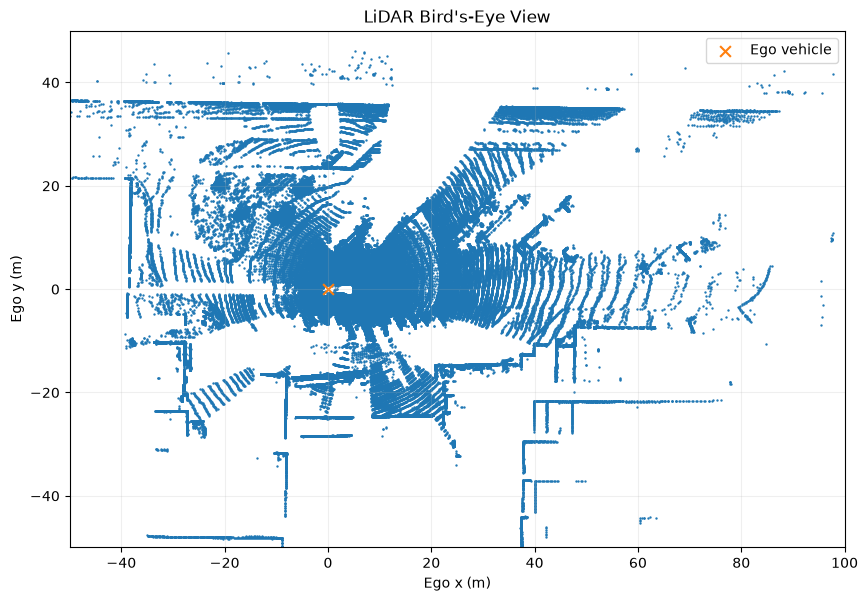

In [18]:
plot_lidar_bev(lidar_points)

In [19]:
#plot_lidar_3d(lidar_points)

# 8. LiDAR Ground Truth Alignment

Ground Truth boxes are transformed into the same ego-vehicle reference frame as the fused LiDAR point cloud. Sensor timestamps are also checked to confirm that the selected LiDAR keyframes are sufficiently aligned with the sample timestamp for the proposed visual comparison.

For the selected sample, the six LiDAR keyframes span approximately 76 ms, with a maximum ego-position difference of approximately 0.18 m. No significant frame mismatch was observed for this visualisation.

In [20]:
sample_boxes = get_sample_boxes_ego(
    truckscenes,
    sample_objects,
)

print("GT boxes:", len(sample_boxes))

GT boxes: 36


In [21]:
sample_timestamp = truckscenes.get(
    "sample",
    selected_sample_token,
)["timestamp"]

timing_records = []

for _, frame in sample_sensor_data[
    sample_sensor_data["Modality"] == "LiDAR"
].iterrows():

    sample_data = truckscenes.get(
        "sample_data",
        frame["Token"],
    )

    ego_pose = truckscenes.get(
        "ego_pose",
        sample_data["ego_pose_token"],
    )

    timing_records.append({
        "Sensor": frame["Sensor"],
        "Time Offset (ms)": (
            sample_data["timestamp"] - sample_timestamp
        ) / 1000,
        "Ego Pose Offset (ms)": (
            ego_pose["timestamp"] - sample_data["timestamp"]
        ) / 1000,
    })

lidar_timing_df = pd.DataFrame(timing_records)

display(lidar_timing_df)

print(
    "LiDAR timestamp span:",
    round(
        lidar_timing_df["Time Offset (ms)"].max()
        - lidar_timing_df["Time Offset (ms)"].min(),
        2,
    ),
    "ms",
)

,Sensor,Time Offset (ms),Ego Pose Offset (ms)
0,LIDAR_LEFT,-10.643,4.384
1,LIDAR_RIGHT,14.018,-0.270
2,LIDAR_TOP_FRONT,2.484,1.264
3,LIDAR_TOP_LEFT,-22.013,-4.097
4,LIDAR_TOP_RIGHT,28.101,-4.219
5,LIDAR_REAR,-48.259,2.008


LiDAR timestamp span: 76.36 ms


In [22]:
reference_pose = truckscenes.getclosest(
    "ego_pose",
    sample_timestamp,
)

reference_position = np.asarray(
    reference_pose["translation"],
    dtype=float,
)

ego_differences = []

for _, frame in sample_sensor_data[
    sample_sensor_data["Modality"] == "LiDAR"
].iterrows():

    sample_data = truckscenes.get(
        "sample_data",
        frame["Token"],
    )

    ego_pose = truckscenes.get(
        "ego_pose",
        sample_data["ego_pose_token"],
    )

    ego_differences.append(
        np.linalg.norm(
            np.asarray(ego_pose["translation"], dtype=float)
            - reference_position
        )
    )

print(
    "Maximum ego-position difference:",
    round(max(ego_differences), 3),
    "m",
)

Maximum ego-position difference: 0.178 m


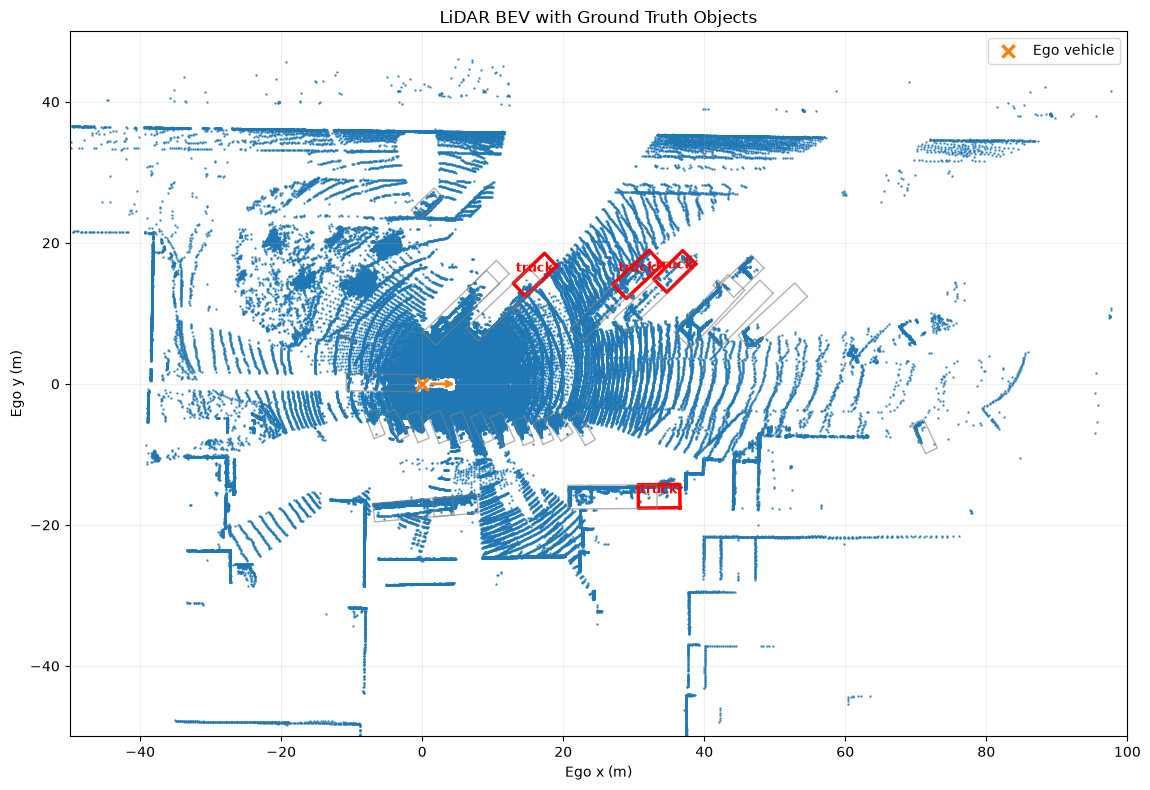

In [23]:
plot_lidar_bev_with_boxes(
    lidar_points,
    sample_boxes,
    highlight_category="vehicle.truck",
    highlight_distance_range=(20, 40),
)

In [24]:
plot_lidar_3d_with_boxes(
    lidar_points,
    sample_boxes,
    highlight_category="vehicle.truck",
    highlight_distance_range=(20, 40),
)